In [154]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # pyright: ignore[reportMissingModuleSource]
import pandas as pd

In [155]:
SEED = 123
torch.manual_seed(SEED)
np.random.seed(SEED)

In [156]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


## Data Analysis

In [157]:
data = load_breast_cancer()

X = data.data
y = data.target

print(f'Samples: {X.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Classes: {data.target_names}')

Samples: 569
Features: 30
Classes: ['malignant' 'benign']


####         class balance

In [158]:
unique, counts = np.unique(y, return_counts=True)

In [159]:
unique

array([0, 1])

In [160]:
counts

array([212, 357])

In [161]:
for cls, cnt in zip(data.target_names, counts):
    print(f'{cls}: {cnt} ({cnt/len(y)*100:.1f}%)')

malignant: 212 (37.3%)
benign: 357 (62.7%)


In [162]:
# WHY: If 95% of samples are class 0, a model that always
# predicts 0 gets 95% accuracy without learning anything.

#### feature ranges

In [163]:
for i in range(5):
    print(f'{data.feature_names[i]:25s} min={X[:,i].min():.2f}  max={X[:,i].max():.2f}')

mean radius               min=6.98  max=28.11
mean texture              min=9.71  max=39.28
mean perimeter            min=43.79  max=188.50
mean area                 min=143.50  max=2501.00
mean smoothness           min=0.05  max=0.16


In [164]:
# WHY: If one feature ranges 0-1 and another ranges 1000-100000,
# the large one dominates gradients. Normalization fixes this.

### Visualization

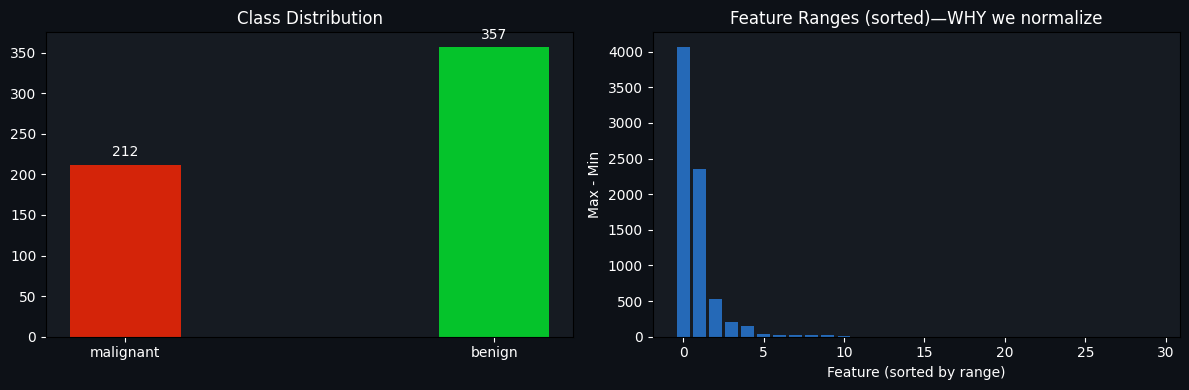


Notice: some features have range ~4000, others ~0.1
Without normalization, large-range features dominate training.


In [165]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1117')

axes[0].set_facecolor('#161b22')
axes[0].bar(data.target_names, counts, color=["#d42409", "#05C32B"], width=0.3)
axes[0].tick_params(colors="#ffffff")
axes[0].set_title('Class Distribution', color='white')

for i, (name, cnt) in enumerate(zip(data.target_names, counts)):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', color='white')



axes[1].set_facecolor('#161b22')
feature_ranges = X.max(axis=0) - X.min(axis=0)
axes[1].bar(range(30), sorted(feature_ranges, reverse=True), color="#297dde", alpha=0.8)
axes[1].set_title('Feature Ranges (sorted)—WHY we normalize', color='white')
axes[1].set_xlabel('Feature (sorted by range)', color="#ffffff")
axes[1].set_ylabel('Max - Min', color="#ffffff")
axes[1].tick_params(colors="#ffffff")

plt.tight_layout()
plt.savefig('01_eda.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\nNotice: some features have range ~4000, others ~0.1')
print('Without normalization, large-range features dominate training.')

### Data Science

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'X train: {X_train.shape[0]}')
print(f'X test: {X_test.shape[0]}')

X train: 455
X test: 114


#### Normalize

Before Scaling Train Mean and STD: 62.0334, 229.8329
Before Scaling Test Mean and STD: 61.3212, 222.0622

After Scaling Train Mean and STD: 0.0000, 1.0000
After Scaling Test Mean and STD: 0.0047, 0.9605


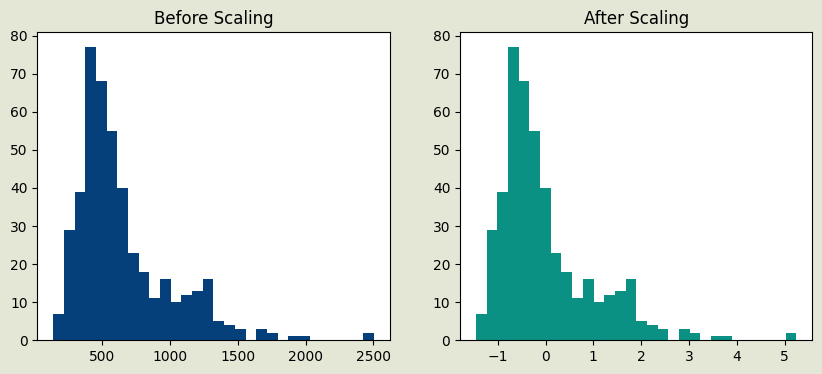

In [167]:
print(f'Before Scaling Train Mean and STD: {X_train.mean():.4f}, {X_train.std():.4f}')
print(f'Before Scaling Test Mean and STD: {X_test.mean():.4f}, {X_test.std():.4f}\n')

feature_idx = 3

plt.figure(figsize=(10,4)).set_facecolor("#E4E7D6")


plt.subplot(1,2,1)
plt.hist(X_train[:, feature_idx], bins=30, color="#05407A")
plt.title("Before Scaling")


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
'''
use TRAIN mean/std
apply same transformation to TEST
'''

print(f'After Scaling Train Mean and STD: {X_train.mean():.4f}, {X_train.std():.4f}')
print(f'After Scaling Test Mean and STD: {X_test.mean():.4f}, {X_test.std():.4f}')
plt.subplot(1,2,2)
plt.hist(X_train[:, feature_idx], bins=30, color="#0B9084")
plt.title("After Scaling")

plt.show()

#### DataSet and DataLoader

In [168]:
class CancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
train_dataset = CancerDataset(X_train, y_train)
test_dataset = CancerDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 15
Test batches: 4


In [169]:
X_batch, y_batch = next(iter(train_loader))

print(f'Batch X shape: {X_batch.shape}')
print(f'Batch y shape: {y_batch.shape}')

Batch X shape: torch.Size([32, 30])
Batch y shape: torch.Size([32, 1])


### Build the Model

In [170]:
class CancerClassifierV2(nn.Module):
    def __init__(self, input_features=30):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.stack(x)
    

class CancerClassifier(nn.Module):
    def __init__(self, input_features=30):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.BatchNorm1d(64),    # ← normalize layer outputs
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.stack(x)

In [171]:
model = CancerClassifier(input_features=30).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

CancerClassifier(
  (stack): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 4,289


In [172]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Training Loop

In [173]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / len(loader), correct / total

In [174]:
EPOCHS = 200
patience = 20          
best_loss = float('inf')
best_weights = None
no_improve = 0

history = {
    'train_loss': [], 
    'val_loss': [], 
    'train_acc': [], 
    'val_acc': []
}

print(f'Training for up to {EPOCHS} epochs (early stopping patience={patience})\n')
print(f'{"Epoch":6} | {"Train Loss":>10} | {"Val Loss":>9} | {"Train Acc":>9} | {"Val Acc":>8}')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_loss:
        best_loss    = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
        flag = '✓'  
    else:
        no_improve += 1
        flag = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | {train_acc*100:>8.1f}% | {val_acc*100:>7.1f}%  {flag}')

    if no_improve >= patience:
        print(f'\nEarly stopping at epoch {epoch} — no improvement for {patience} epochs')
        break


model.load_state_dict(best_weights)
print(f'\nRestored best weights (val_loss={best_loss:.4f})')

Training for up to 200 epochs (early stopping patience=20)

Epoch  | Train Loss |  Val Loss | Train Acc |  Val Acc
     1 |     0.6426 |    0.5319 |     63.3% |    93.9%  ✓
    10 |     0.1972 |    0.1528 |     95.2% |    96.5%  ✓
    20 |     0.1701 |    0.0731 |     95.8% |    99.1%  ✓
    30 |     0.0893 |    0.0594 |     96.7% |    98.2%  
    40 |     0.0663 |    0.0491 |     97.8% |    99.1%  ✓
    50 |     0.0947 |    0.0496 |     98.0% |    99.1%  
    60 |     0.1053 |    0.0522 |     97.1% |    98.2%  

Early stopping at epoch 66 — no improvement for 20 epochs

Restored best weights (val_loss=0.0435)


### Evaluate & Visualize

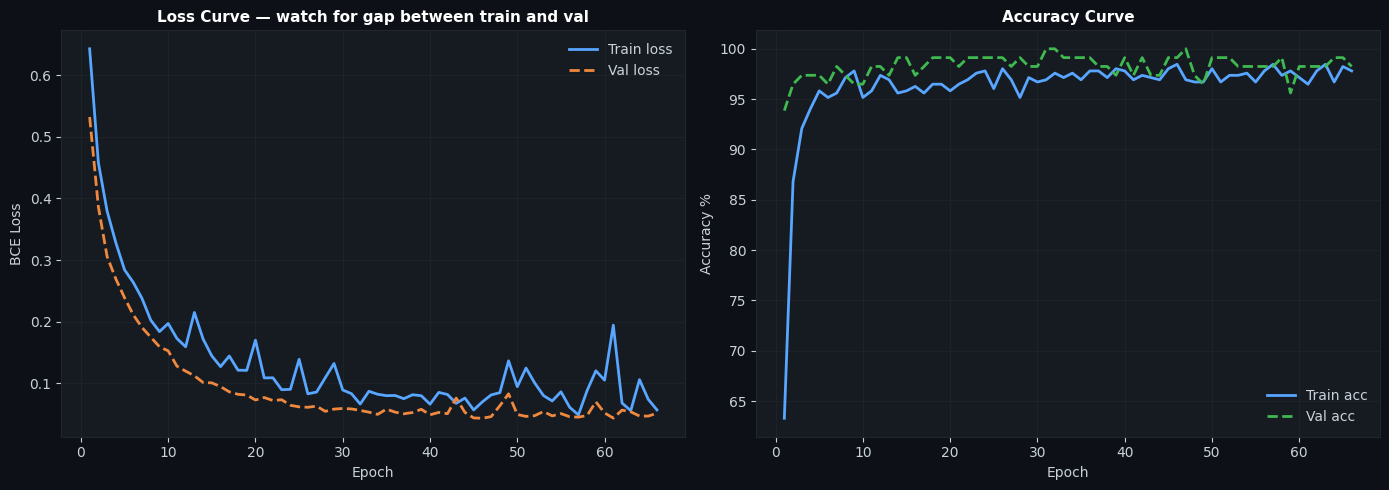

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')

def style(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    for s in ax.spines.values(): s.set_edgecolor('#21262d')
    ax.grid(True, color='#21262d', linewidth=0.5)

epochs_ran = range(1, len(history['train_loss']) + 1)

style(axes[0], 'Loss Curve — watch for gap between train and val')
axes[0].plot(epochs_ran, history['train_loss'], color='#58a6ff', label='Train loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'], color='#f0883e', label='Val loss', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(framealpha=0, labelcolor='#c9d1d9')

style(axes[1], 'Accuracy Curve')
axes[1].plot(epochs_ran, [a*100 for a in history['train_acc']], color='#58a6ff', label='Train acc', linewidth=2)
axes[1].plot(epochs_ran, [a*100 for a in history['val_acc']], color='#3fb950', label='Val acc', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy %')
axes[1].legend(framealpha=0, labelcolor='#c9d1d9')

plt.tight_layout()
plt.savefig('02_training_curves.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### Final evaluation

In [176]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.sigmoid(logits)
        preds   = (probs >= 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()
all_probs  = np.array(all_probs).flatten()

print(classification_report(all_labels, all_preds, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        42
      benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



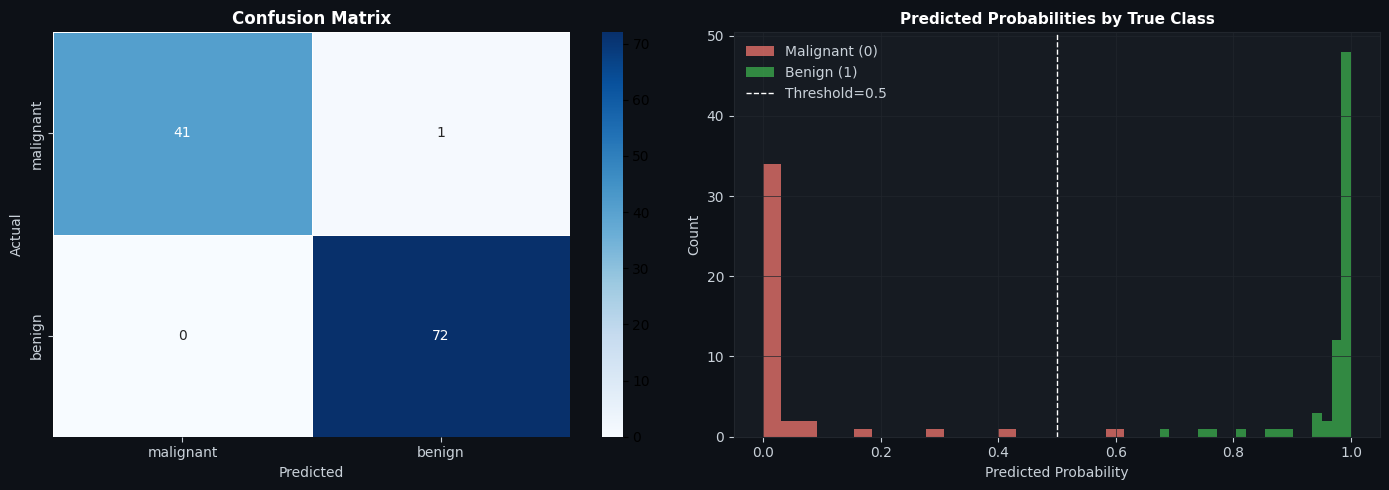

In [177]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')

axes[0].set_facecolor('#161b22')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', color='white', fontweight='bold')
axes[0].set_xlabel('Predicted', color='#c9d1d9')
axes[0].set_ylabel('Actual', color='#c9d1d9')
axes[0].tick_params(colors='#c9d1d9')
# Top-left:  True Negatives (correctly predicted malignant)
# Top-right: False Positives(predicted benign, actually malignant) ← dangerous!
# Bot-left: False Negatives (predicted malignant, actually benign)
# Bot-right: True Positives (correctly predicted benign)

style(axes[1], 'Predicted Probabilities by True Class')
axes[1].hist(all_probs[all_labels==0], bins=20, alpha=0.7, color='#ff7b72', label='Malignant (0)')
axes[1].hist(all_probs[all_labels==1], bins=20, alpha=0.7, color='#3fb950', label='Benign (1)')
axes[1].axvline(0.5, color='white', linestyle='--', linewidth=1, label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability'); 
axes[1].set_ylabel('Count')
axes[1].legend(framealpha=0, labelcolor='#c9d1d9')
# Good model: two peaks pushed to opposite ends (0 and 1), minimal overlap

plt.tight_layout()
plt.savefig('03_evaluation.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### Save The Model

In [178]:
import pickle

torch.save(model.state_dict(), 'cancer_model.pth')

In [179]:
with open('cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved scaler, cancer_scaler.pkl')

Saved scaler, cancer_scaler.pkl


In [180]:
print('\n=== How to load and predict on new data ===')


=== How to load and predict on new data ===


In [181]:
loaded_model = CancerClassifier(input_features=30)
loaded_model.load_state_dict(torch.load('cancer_model.pth', weights_only=True))
loaded_model.eval()

with open('cancer_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

new_patient = X_test[0:1]                          
new_scaled  = loaded_scaler.transform(new_patient) 
new_tensor  = torch.tensor(new_scaled, dtype=torch.float32)

with torch.no_grad():
    logit = loaded_model(new_tensor)
    prob  = torch.sigmoid(logit).item()
    pred  = 'benign' if prob >= 0.5 else 'malignant'

print(f'\nPrediction: {pred} (probability of benign: {prob:.4f})')
print(f'True label: {data.target_names[int(y_test[0])]}')


Prediction: malignant (probability of benign: 0.0000)
True label: malignant
